# LightGBM Regression – Product Sales Prediction
Đọc dữ liệu → làm sạch → lưu dữ liệu sạch → chia Train/Test 80/20 → huấn luyện LightGBM → đánh giá → trực quan hóa.


In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm_regression import LightGBMRegression
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor
print("Import LightGBMRegression thành công.") 

Import LightGBMRegression thành công.


In [49]:
df = pd.read_csv("data/raw/market_data.csv")
print("===== DỮ LIỆU GỐC =====")
display(df.head())
print("Shape:", df.shape)


===== DỮ LIỆU GỐC =====


,Sale,InStrSpending,Discount,TVSpending,StockRate,Price,Radio,OnlineAdsSpending
0,240368,59.90,0.46,46.30,0.45,12.56,1065,1081.60
1,207276,7.28,0.39,166.91,0.05,5.44,1832,651.24
2,172572,9.81,0.41,73.67,0.06,3.54,587,1066.56
3,82697,46.94,0.27,33.95,0.88,28.90,1407,1855.27
4,141762,2.59,0.26,82.63,0.36,4.66,2057,1608.91


Shape: (992, 8)


In [50]:
print("===== THÔNG TIN DATASET =====")
df.info()
print("\n===== GIÁ TRỊ THIẾU =====")
print(df.isnull().sum())
print("\nSố dòng trùng:", df.duplicated().sum())


===== THÔNG TIN DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sale               992 non-null    int64  
 1   InStrSpending      992 non-null    float64
 2   Discount           992 non-null    float64
 3   TVSpending         992 non-null    float64
 4   StockRate          992 non-null    float64
 5   Price              992 non-null    float64
 6   Radio              992 non-null    int64  
 7   OnlineAdsSpending  992 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 62.1 KB

===== GIÁ TRỊ THIẾU =====
Sale                 0
InStrSpending        0
Discount             0
TVSpending           0
StockRate            0
Price                0
Radio                0
OnlineAdsSpending    0
dtype: int64

Số dòng trùng: 0


In [51]:
df = df.drop_duplicates().copy()
for column in df.columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        df[column] = df[column].fillna(df[column].median())
    else:
        mode_values = df[column].mode()
        if not mode_values.empty:
            df[column] = df[column].fillna(mode_values.iloc[0])
print("Giá trị thiếu sau xử lý:")
print(df.isnull().sum())
print("Số dòng trùng sau xử lý:", df.duplicated().sum())


Giá trị thiếu sau xử lý:
Sale                 0
InStrSpending        0
Discount             0
TVSpending           0
StockRate            0
Price                0
Radio                0
OnlineAdsSpending    0
dtype: int64
Số dòng trùng sau xử lý: 0


In [52]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Các cột categorical:", categorical_columns)
if categorical_columns:
    df = pd.get_dummies(df, columns=categorical_columns, drop_first=False, dtype=int)
    print("Đã mã hóa categorical thành số.")
else:
    print("Dataset chỉ có dữ liệu số, không cần mã hóa.")


Các cột categorical: []
Dataset chỉ có dữ liệu số, không cần mã hóa.


In [53]:
os.makedirs("data/processed", exist_ok=True)
clean_path = "data/processed/regression_cleaned.csv"
df.to_csv(clean_path, index=False)
print("Đã lưu:", clean_path)


Đã lưu: data/processed/regression_cleaned.csv


In [54]:
TARGET = "Sale"
X_features = df.drop(columns=[TARGET])
y_label = df[TARGET]
print("Features:", X_features.columns.tolist())
print("Target:", TARGET)


Features: ['InStrSpending', 'Discount', 'TVSpending', 'StockRate', 'Price', 'Radio', 'OnlineAdsSpending']
Target: Sale


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=101
)
print("X_train shape :", X_train.shape)
print("y_train shape :", y_train.shape)
print("=" * 20)
print("X_test shape  :", X_test.shape)
print("y_test shape  :", y_test.shape)


X_train shape : (793, 7)
y_train shape : (793,)
X_test shape  : (199, 7)
y_test shape  : (199,)


In [56]:
model = LightGBMRegression(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42
)
model.fit(X_train, y_train)
print("Huấn luyện mô hình thành công.")


Đang tiến hành huấn luyện (fit)...
Huấn luyện hoàn tất!
Huấn luyện mô hình thành công.


In [57]:
y_pred = model.predict(X_test)
print("Số giá trị dự đoán:", len(y_pred))
print("5 dự đoán đầu:", y_pred[:5])


Đang tiến hành dự đoán (predict)...
Số giá trị dự đoán: 199
5 dự đoán đầu: [ 38824.8427708  173496.36220502 185487.3055119  150036.22169879
 239755.09400279]


In [58]:
mse_train = mean_squared_error(y_train, model.predict(X_train))
mse_test = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE) trên tập kiểm tra:", mse_test)
print("Mean Squared Error (MSE) trên tập huấn luyện:", mse_train)

r2_train = r2_score(y_train, model.predict(X_train))
r2_test = r2_score(y_test, y_pred)
print("R-squared (R2) trên tập kiểm tra:", r2_test)
print("R-squared (R2) trên tập huấn luyện:", r2_train)



Đang tiến hành dự đoán (predict)...
Mean Squared Error (MSE) trên tập kiểm tra: 42929162.68488396
Mean Squared Error (MSE) trên tập huấn luyện: 3488281.9601445245
Đang tiến hành dự đoán (predict)...
R-squared (R2) trên tập kiểm tra: 0.9937298016943141
R-squared (R2) trên tập huấn luyện: 0.9994679265748131


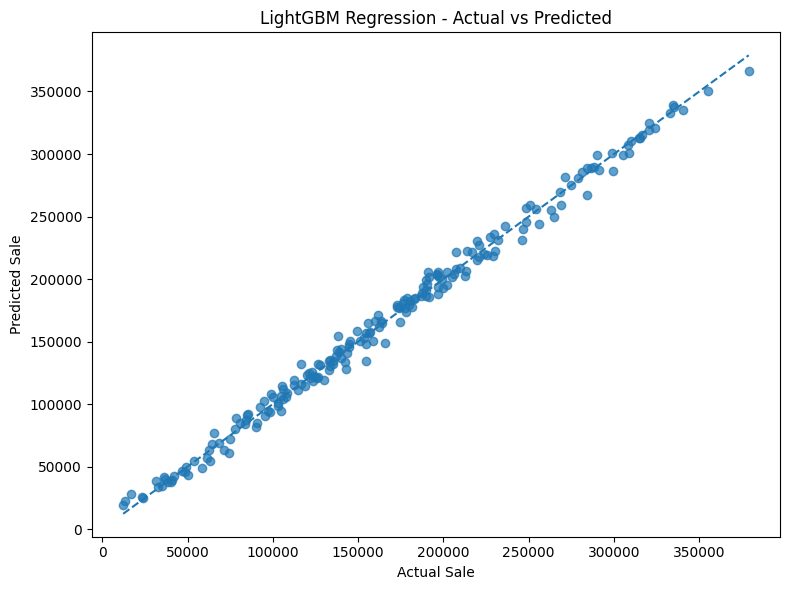

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Sale")
plt.ylabel("Predicted Sale")
plt.title("LightGBM Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()


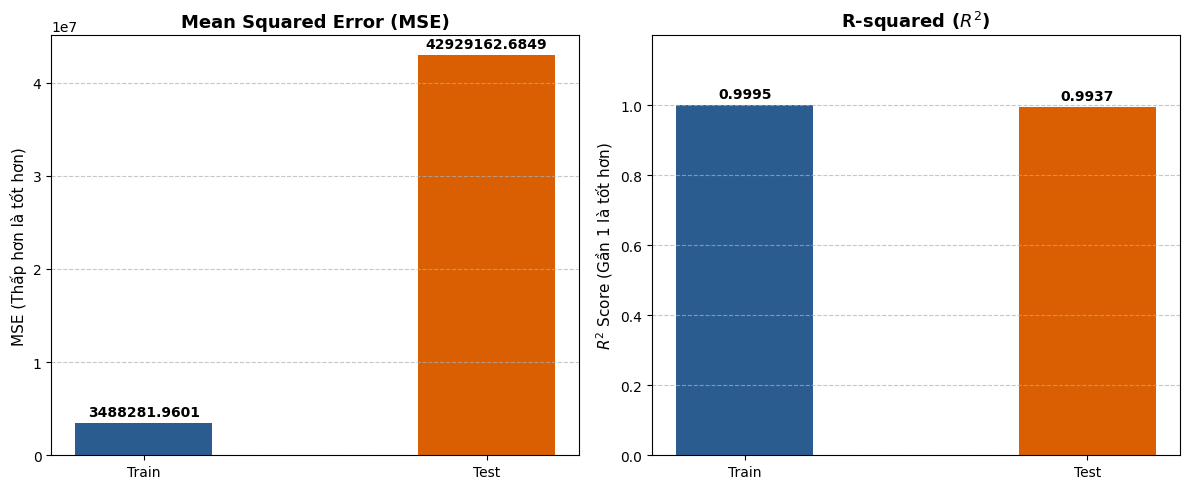

In [60]:
import matplotlib.pyplot as plt

# 1. Khởi tạo khung vẽ gồm 2 biểu đồ con (subplots) nằm ngang
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ["Train", "Test"]
colors = ["#2b5c8f", "#d95f02"]  # Xanh dương cho Train, Cam cho Test

# --- BIỂU ĐỒ 1: MEAN SQUARED ERROR (MSE) ---
mse_values = [mse_train, mse_test]
bars_mse = axes[0].bar(categories, mse_values, color=colors, width=0.4)
axes[0].set_title("Mean Squared Error (MSE)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("MSE (Thấp hơn là tốt hơn)", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Hiển thị số liệu chi tiết trên đầu mỗi cột
for bar in bars_mse:
    height = bar.get_height()
    axes[0].annotate(
        f"{height:.4f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# --- BIỂU ĐỒ 2: R-SQUARED (R2) ---
r2_values = [r2_train, r2_test]
bars_r2 = axes[1].bar(categories, r2_values, color=colors, width=0.4)
axes[1].set_title("R-squared ($R^2$)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("$R^2$ Score (Gần 1 là tốt hơn)", fontsize=11)
axes[1].set_ylim(
    0, max(max(r2_values) * 1.2, 1.0)
)  # Tự động giới hạn trục Y
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Hiển thị số liệu chi tiết trên đầu mỗi cột
for bar in bars_r2:
    height = bar.get_height()
    axes[1].annotate(
        f"{height:.4f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Căn chỉnh bố cục và hiển thị
plt.tight_layout()
plt.show()

,Feature,Importance
4,Price,1.269163e+13
0,InStrSpending,9.090423e+12
2,TVSpending,4.779518e+12
3,StockRate,2.604041e+11
1,Discount,2.464679e+11
5,Radio,1.684801e+11
6,OnlineAdsSpending,1.149856e+11


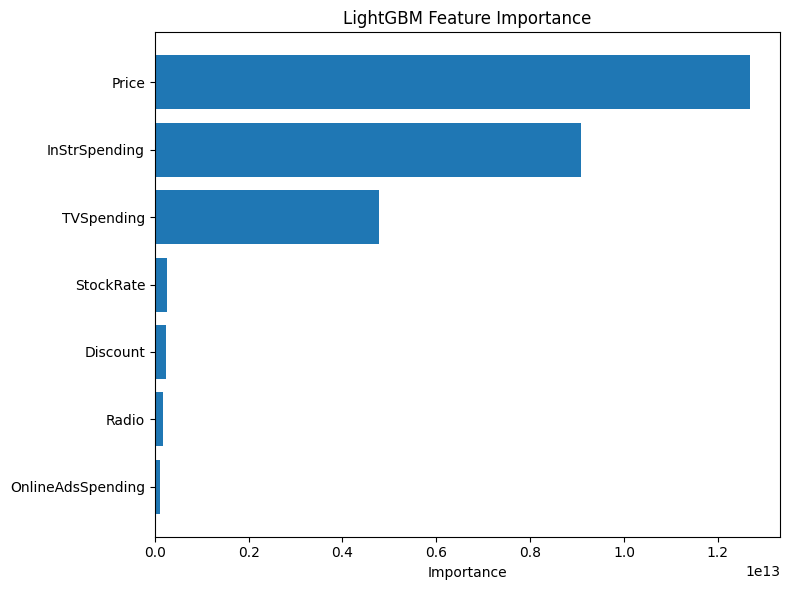

In [61]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)
display(importance)
plt.figure(figsize=(8, 6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()


In [64]:

model_test = LGBMRegressor(
    n_estimators=200)

model_test.fit(X_train, y_train)
ketqua_mse = mean_squared_error(y_test, model_test.predict(X_test))
ketqua_r2 = r2_score(y_test, model_test.predict(X_test))
print("Kết quả MSE:", ketqua_mse)
print("Kết quả R2:", ketqua_r2)

ketqua_mse_train = mean_squared_error(y_train, model_test.predict(X_train))
ketqua_r2_train = r2_score(y_train, model_test.predict(X_train))
print("Kết quả MSE (Train):", ketqua_mse_train)
print("Kết quả R2 (Train):", ketqua_r2_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1426
[LightGBM] [Info] Number of data points in the train set: 793, number of used features: 7
[LightGBM] [Info] Start training from score 172405.402270
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai